# Portafolios en Python: de Markowitz a risk parity
### Clase 5: Práctica
**Finanzas Cuantitativas, la Ciencia y los Mercados**
FCEN-UBA · Guido Schifani

---

| Ejercicio | Tema | Qué hacemos |
|---|---|---|
| **1** | Frontera eficiente | 12 acciones reales, máximo Sharpe, el **colapso out-of-sample**, y por qué Ledoit-Wolf por sí solo no alcanza a curarlo |
| **2** | Black-Litterman | Despejar los μ del mercado, meter un view, ver la cartera rotar (sin volverse loca) |
| **3** | Risk parity vs. Equal Weight | Backtest 2007-2026 (con la crisis de 2008 adentro): ¿le gana risk parity a 1/N? |


> **Antes de arrancar — predíganlo todo:**
>
> La regla del laboratorio de hoy: escriban su predicción ANTES de correr cada bloque de
> código. Las juntamos todas acá arriba para que las escriban de una sola vez, antes de
> contaminarse con el resultado de un ejercicio al predecir el siguiente.
>
>
> **Ejercicio 1 (Frontera eficiente):**
> 1. ¿Esperás que el Sharpe out-of-sample del portafolio óptimo sea MEJOR, IGUAL o PEOR que el in-sample? Poné un número aproximado para cada uno.
> 2. ¿El optimizador de máximo Sharpe va a repartir el peso parejo entre las 12 acciones, o concentrarse en pocas? ¿Cuántas creés que van a sobrevivir con peso > 1%?
>
> **Ejercicio 2 (Black-Litterman):**
> 1. Si el view dice "tech +2% anual" pero el equilibrio YA descuenta más que eso, ¿la cartera resultante va a tener MÁS o MENOS tech que el mercado?
>
> **Ejercicio 3 (Risk Parity):**
> 1. ¿Creés que Risk Parity le va a ganar a 1/N en Sharpe, en TODA la ventana 2007-2026? Arriesgá un número aproximado para cada uno.


In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from scipy.optimize import minimize
from scipy.cluster.hierarchy import linkage
from scipy.spatial.distance import squareform
import warnings
warnings.filterwarnings('ignore')

NAVY, VIOLET, ORANGE = '#1E1B4B', '#4B3FA0', '#E8602C'
GREEN, RED, MGRAY = '#2E7D32', '#C62828', '#8A8A9A'
plt.rcParams.update({'figure.figsize': (10, 4.5), 'axes.grid': True, 'grid.alpha': 0.3})
rf = 0.04   # tasa libre de riesgo anual de referencia
print('Listo.')

Listo.


---
# Ejercicio 1: La frontera eficiente y su colapso out-of-sample

## La idea

Markowitz con 12 acciones reales, hecho con honestidad estadística:

1. Estimamos $\mu$ y $\Sigma$ con los **primeros 3 años** (in-sample).
2. Construimos la frontera y el portafolio de **máximo Sharpe** (scipy, long-only).
3. Y el momento de la verdad: aplicamos esos pesos a los **2 años siguientes** que el
   optimizador nunca vio, contra el benchmark humilde: **1/N**.

$$\max_w \frac{w^\top\mu - r_f}{\sqrt{w^\top\Sigma\,w}} \qquad \text{s.a.}\quad \textstyle\sum_i w_i = 1,\ w_i \ge 0$$

**Predicción de la teórica (§2):** el optimizador ama los errores de estimación, va a
concentrar la cartera en lo que tuvo suerte in-sample, y el Sharpe out-of-sample se va a desinflar.

> *(Predicción: Ejercicio 1 (Frontera eficiente), ya la escribiste arriba de todo, antes de empezar.)*

In [12]:
TICKERS = ['AAPL', 'MSFT', 'NVDA', 'JPM', 'GS', 'XOM', 'CVX', 'KO', 'PG', 'UNH', 'CAT', 'DIS']

try:
    px = yf.download(TICKERS, period='5y', progress=False)['Close'].dropna()[TICKERS]
    fuente = 'datos en vivo (Yahoo Finance)'
except Exception as e:
    fuente = f'⚠ respaldo sintético ({e})'
    rng = np.random.default_rng(5)
    idx = pd.date_range('2021-07-01', periods=1250, freq='B')
    mkt = rng.normal(0.0004, 0.01, 1250)
    px = pd.DataFrame({t: 100*np.exp(np.cumsum(0.0001 + (0.7+0.1*i)*mkt + rng.normal(0, 0.012, 1250)))
                       for i, t in enumerate(TICKERS)}, index=idx)

rets = np.log(px/px.shift(1)).dropna()[TICKERS]
corte = int(len(rets)*0.6)                      # ~3 años train / ~2 test
r_tr, r_te = rets[:corte], rets[corte:]
mu  = r_tr.mean().values * 252                  # μ anualizado (in-sample)
Sig = r_tr.cov().values * 252                   # Σ anualizada (in-sample)
print(f'[{fuente}] {len(r_tr)} días de estimación | {len(r_te)} días out-of-sample')

[datos en vivo (Yahoo Finance)] 751 días de estimación | 502 días out-of-sample


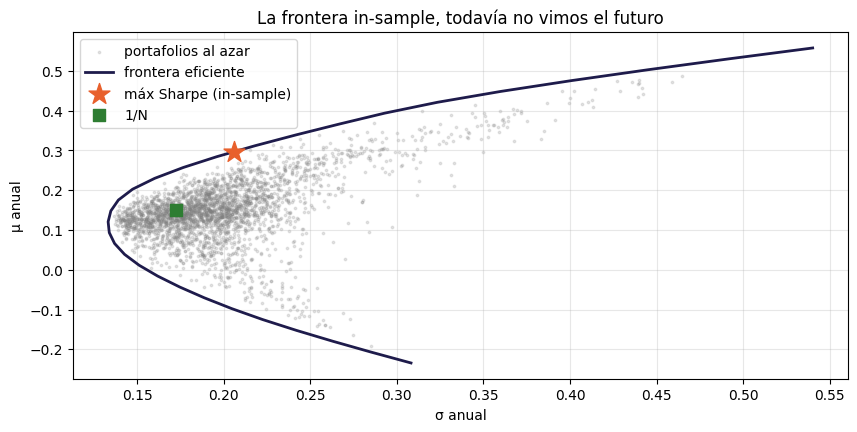

Pesos del máximo Sharpe (in-sample):
XOM     0.418
KO      0.289
NVDA    0.251
UNH     0.042

→ 4 de 12 activos con peso > 1%, el optimizador CONCENTRA


In [13]:
# ── Máximo Sharpe (long-only) + frontera ──────────────────────────────────────
N = len(TICKERS)
restr  = [{'type': 'eq', 'fun': lambda w: w.sum() - 1}]
cotas  = [(0, 1)]*N
w0     = np.ones(N)/N

def vol(w, S=Sig): return np.sqrt(w @ S @ w)
def neg_sharpe(w): return -(w @ mu - rf) / vol(w)

w_ms = minimize(neg_sharpe, w0, method='SLSQP', bounds=cotas, constraints=restr).x
w_1n = w0.copy()

frontera, pesos_frontera = [], []
for r_obj in np.linspace(mu.min(), mu.max()*0.98, 30):
    r = minimize(vol, w0, method='SLSQP', bounds=cotas,
                 constraints=restr + [{'type': 'eq', 'fun': lambda w, ro=r_obj: w @ mu - ro}])
    if r.success:
        frontera.append((r.fun, r_obj))
        pesos_frontera.append(r.x)

rng = np.random.default_rng(0)
W = rng.dirichlet(np.full(N, 0.3), 3000)
plt.scatter((W @ Sig * W).sum(1)**0.5, W @ mu, s=3, alpha=0.2, color='gray', label='portafolios al azar')
plt.plot(*zip(*frontera), color=NAVY, lw=2, label='frontera eficiente')
plt.scatter(vol(w_ms), w_ms @ mu, marker='*', s=250, color=ORANGE, zorder=3, label='máx Sharpe (in-sample)')
plt.scatter(vol(w_1n), w_1n @ mu, marker='s', s=80, color=GREEN, label='1/N')
plt.xlabel('σ anual'); plt.ylabel('μ anual'); plt.legend()
plt.title('La frontera in-sample, todavía no vimos el futuro'); plt.show()

conc = pd.Series(w_ms, index=TICKERS).sort_values(ascending=False)
print('Pesos del máximo Sharpe (in-sample):')
print(conc[conc > 0.01].round(3).to_string())
print(f'\n→ {int((w_ms > 0.01).sum())} de {N} activos con peso > 1%, el optimizador CONCENTRA')

In [14]:
# ── El momento de la verdad: out-of-sample ────────────────────────────────────
def sharpe_realizado(w, r):
    serie = r @ w
    return (serie.mean()*252 - rf) / (serie.std()*np.sqrt(252))

print(f'{"":<22}{"Sharpe in-sample":>18}{"Sharpe out-of-sample":>22}')
for nombre, w in [('Máx Sharpe (Markowitz)', w_ms), ('1/N ingenuo', w_1n)]:
    print(f'{nombre:<22}{sharpe_realizado(w, r_tr):>18.2f}{sharpe_realizado(w, r_te):>22.2f}')

print()
print('El colapso: el Sharpe optimizado se desinfla fuera de muestra; el 1/N casi no.')
print('DeMiguel et al. (2009): esto no es mala suerte, es la regla.')

                        Sharpe in-sample  Sharpe out-of-sample
Máx Sharpe (Markowitz)              1.25                  1.00
1/N ingenuo                         0.64                  0.91

El colapso: el Sharpe optimizado se desinfla fuera de muestra; el 1/N casi no.
DeMiguel et al. (2009): esto no es mala suerte, es la regla.


### La cura: shrinkage de Ledoit-Wolf

$$\hat\Sigma_{LW} = (1-\alpha)\,\hat\Sigma_{muestral} + \alpha\,F, \qquad F = \bar\mu\cdot I$$

con $\alpha$ elegido por **fórmula cerrada** (Ledoit-Wolf, 2004), no cross-validation.

In [15]:
# ── Ledoit-Wolf shrinkage de Σ̂ ────────────────────────────────────────────────
from sklearn.covariance import LedoitWolf

lw = LedoitWolf().fit(r_tr)
Sig_lw = lw.covariance_ * 252
print(f'Intensidad de shrinkage óptima: α = {lw.shrinkage_:.2f}  (0 = pura Σ̂ muestral, 1 = puro F=μ̄I)')

w_ms_lw = minimize(lambda w: -(w @ mu - rf) / vol(w, Sig_lw), w0,
                   method='SLSQP', bounds=cotas, constraints=restr).x

print(f'\n{"":<26}{"Sharpe in-sample":>18}{"Sharpe out-of-sample":>22}')
for nombre, w in [('Máx Sharpe (Σ̂ muestral)', w_ms), ('Máx Sharpe (Σ̂ Ledoit-Wolf)', w_ms_lw), ('1/N ingenuo', w_1n)]:
    print(f'{nombre:<26}{sharpe_realizado(w, r_tr):>18.2f}{sharpe_realizado(w, r_te):>22.2f}')

Intensidad de shrinkage óptima: α = 0.01  (0 = pura Σ̂ muestral, 1 = puro F=μ̄I)

                            Sharpe in-sample  Sharpe out-of-sample
Máx Sharpe (Σ̂ muestral)                1.25                  1.00
Máx Sharpe (Σ̂ Ledoit-Wolf)              1.25                  0.98
1/N ingenuo                             0.64                  0.91


**Lectura honesta (fracaso instructivo): ¿por qué no cambió casi nada?**

Ledoit-Wolf encoge $\hat\Sigma$, no toca $\hat\mu$ — son curas para enfermedades distintas.
Con $N=12$ tickers y $T\approx750$ días, $N/T\approx0.016$: muy lejos del régimen crítico de
Marchenko-Pastur ($N/T\to1$) donde $\hat\Sigma$ es puro ruido y el shrinkage tiene mucho para
corregir. Acá $\hat\Sigma$ ya estaba razonablemente bien estimada — por eso el propio
estimador elige $\alpha\approx0.01$, casi no encoger nada, no es que el método "no
funcione". El verdadero culpable del colapso out-of-sample es $\hat\mu$ (la clase 4 ya mostró
lo ruidoso que es estimar retornos esperados), y a $\hat\mu$ Ledoit-Wolf ni lo mira. Por eso
Black-Litterman (Ejercicio 2, a continuación) sí ataca la causa real: deja de estimar μ
desde cero.

---
# Ejercicio 2, Black-Litterman: un view sin volverse loco

## La idea

**Veníamos de ver** (bonus del Ejercicio 1) que alimentar a Markowitz con μ̂ histórico es
pararlo sobre el filo de una navaja: un error de estimación de una décima de punto
porcentual puede invertir la cartera entera. Black-Litterman (1990, Goldman Sachs) no le
pone un parche al síntoma con más regularización, ataca la causa: **deja de estimar μ desde
cero**. La lógica es un update bayesiano de un solo paso — literalmente el mismo álgebra que
un filtro de Kalman con una sola observación, o una regresión de proceso gaussiano (van a
volver a ver esta cuenta en la clase 7):

1. **Prior**: si el mercado está en equilibrio (CAPM), los pesos $w_{mkt}$ que observamos HOY
   ya revelan qué retornos "cree" el mercado — en vez de aplicar el CAPM (μ conocido → pesos
   de equilibrio), lo invertimos (pesos observados → μ de equilibrio implícito):
   $$\Pi = \delta\,\Sigma\,w_{mkt}, \qquad \delta \approx 2.5 \text{ (aversión al riesgo del mercado)}$$
   Π no se mide con ruido: se **despeja** de $w_{mkt}$ (observable) y $\Sigma$ (que en el
   Ejercicio 1 vimos que se estima razonablemente bien). La primera humildad de Black-Litterman
   es esta: nadie estima μ a mano, el mercado agregado ya lo hizo.

2. **Evidencia**: tu view, expresado como una afirmación sobre una combinación lineal de
   activos. Hoy: *"tecnología le gana al resto del mercado por 2% anual"*. Se traduce en tres
   objetos — $P$ (qué combinación de activos describe el view), $Q$ (el número del view) y
   $\Omega$ (cuánta incertidumbre le ponés: chico = mucha confianza, grande = poca — el dial
   escepticismo-convicción que van a mover en la Pregunta 2).

3. **Posterior**: combinar prior y evidencia con la fórmula estándar de combinación gaussiana
   (prior $\mathcal{N}(\Pi,\tau\Sigma)$, likelihood del view $\mathcal{N}(Q,\Omega)$):
   $$\mu_{BL} = \Pi + \tau\Sigma P^\top\left(P\tau\Sigma P^\top + \Omega\right)^{-1}(Q - P\,\Pi)$$
   $\tau$ es un escalar chico (0.01-0.05) que escala la incertidumbre del PRIOR — no la de los
   retornos en sí — o sea, cuánto confiás en que Π es el equilibrio verdadero.

Universo: los 10 sectores del S&P 500 (ETFs XL*), con sus pesos de mercado reales como $w_{mkt}$.

### El mapa completo, en 6 pasos (antes de entrar en la fórmula)

Antes de la fórmula completa, el panorama entero, en orden — para no perderse en el medio:

1. **w_mkt — un DATO, no un cálculo.** Los pesos reales del mercado (cuánta plata hay
   invertida en cada sector, HOY). No sale de ningún modelo: se observa.
2. **Σ — se estima** de datos históricos de precios (igual que en el Ejercicio 1).
3. **Π = δΣw_mkt — el PRIOR.** La pregunta que responde: "si el mercado está en equilibrio,
   ¿qué retornos esperados harían que w_mkt fuera la cartera óptima?". Π no tiene el ruido de
   un promedio histórico — se **despeja**, no se estima.
4. **Tu view: P, Q, Ω.** Qué activo(s) toca (P), qué dice (Q, ej. "+2%"), cuánta confianza le
   tenés (Ω).
5. **μ_BL = combinar Π + (P,Q,Ω) con Bayes → el POSTERIOR.** Un nuevo vector de retornos
   esperados, mezcla de lo que el mercado ya sabe y lo que vos creés.
6. **Markowitz con μ_BL** (la misma fórmula del Ejercicio 1: w\*=(δΣ)⁻¹μ) → el portafolio final.

**Black-Litterman NO reemplaza a Markowitz** — le da un μ mejor (μ_BL en vez de μ̂ crudo) para
que el paso 6 no se vuelva loco, como vimos que pasaba en el bonus del Ejercicio 1.

> **Un caso particular que van a ver en el código, "Π puro":** es el paso 6 salteándose el
> 4 y el 5 (sin view, usando Π directo como si fuera μ_BL). Como Π se construyó justamente
> para que w_mkt fuera la respuesta del paso 6, hacer ese camino de ida (paso 3) y volver
> (paso 6) es circular — por eso da w_mkt EXACTO de vuelta. No es un resultado nuevo, es el
> *sanity check* de que las fórmulas están bien armadas.

> *(Predicción: Ejercicio 2 (Black-Litterman), ya la escribiste arriba de todo, antes de empezar.)*

In [16]:
SECTORES = {'XLK': 0.32, 'XLF': 0.13, 'XLV': 0.11, 'XLY': 0.11, 'XLI': 0.09,
            'XLC': 0.09, 'XLP': 0.06, 'XLE': 0.03, 'XLU': 0.025, 'XLB': 0.02}
# pesos aprox. del S&P por sector (hardcodeados, actualizar antes de la clase)
tks = list(SECTORES)
w_mkt = np.array(list(SECTORES.values())); w_mkt = w_mkt / w_mkt.sum()

try:
    pxs = yf.download(tks, period='5y', progress=False)['Close'].dropna()
    fuente = 'datos en vivo'
except Exception as e:
    fuente = f'⚠ respaldo sintético ({e})'
    rng = np.random.default_rng(7)
    idx = pd.date_range('2021-07-01', periods=1250, freq='B')
    mkt = rng.normal(0.0004, 0.009, 1250)
    pxs = pd.DataFrame({t: 100*np.exp(np.cumsum((0.8+0.08*i)*mkt + rng.normal(0, 0.007, 1250)))
                        for i, t in enumerate(tks)}, index=idx)

rs = np.log(pxs/pxs.shift(1)).dropna()[tks]
S  = rs.cov().values * 252
mu_hist = rs.mean().values * 252

delta = 2.5
Pi = delta * S @ w_mkt
print(f'[{fuente}] Retornos implícitos Π (el mercado "cree"):')
print(pd.Series(Pi, index=tks).map('{:+.1%}'.format).to_string())

[datos en vivo] Retornos implícitos Π (el mercado "cree"):
XLK    +10.2%
XLF     +6.4%
XLV     +4.1%
XLY     +9.2%
XLI     +6.6%
XLC     +7.5%
XLP     +2.8%
XLE     +4.3%
XLU     +3.3%
XLB     +6.5%


### Cómo se arma un view relativo (P, Q, Ω)

Nuestro view no es "XLK va a rendir +2%" en términos absolutos, es **relativo**: "XLK le gana
al resto del mercado por 2%". Eso cambia cómo se codifica:

$$P = \underbrace{\mathbf{1}_{XLK}}_{+1 \text{ en XLK}} - \underbrace{w_{mkt}}_{\text{el resto, ponderado}}$$

de forma que $P\mu$ es exactamente "retorno de XLK menos el retorno de la cartera de
mercado" — es lo que hace la línea `P[0] = -w_mkt; P[0, tks.index('XLK')] += 1` de abajo.
$Q=0.02$ es el número del view (el +2%). Y para $\Omega$ usamos la elección estándar de
He-Litterman (1999): $\Omega = P(\tau\Sigma)P^\top$, es decir, la incertidumbre del view es
proporcional a la incertidumbre que YA tiene el prior en esa misma dirección — ni más
confiado ni menos que el propio equilibrio de mercado.

El view dice: XLK − mercado = +2%. El equilibrio YA implica: +2.8%
→ decir "+2%" cuando el mercado descuenta más es un view BAJISTA en tech.



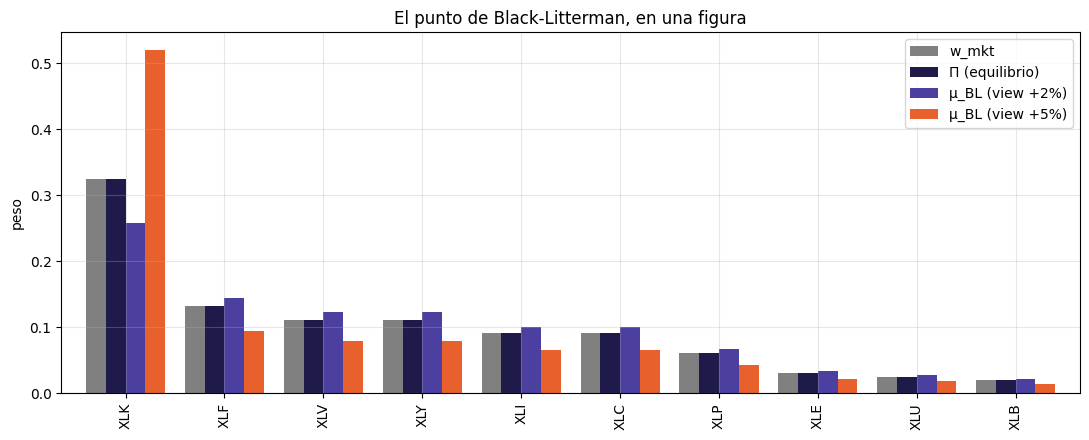

Lectura:
 - μ̂ histórico → posiciones salvajes: suma |w| = 11.5 (vs 1.0 del mercado)
 - Π puro      → recupera w_mkt EXACTAMENTE, el sanity check
 - View +2%    → XLK 26% vs 32%: tilt BAJISTA
 - View +5%    → XLK 52%: tilt alcista


In [17]:
# ── El view y el posterior ────────────────────────────────────────────────────
P = np.zeros((1, len(tks)))
P[0] = -w_mkt; P[0, tks.index('XLK')] += 1
tau = 0.05
Omega = np.atleast_2d(P @ (tau*S) @ P.T)

implicito = float(P @ Pi)
print(f'El view dice: XLK − mercado = +2%. El equilibrio YA implica: {implicito:+.1%}')
print('→ decir "+2%" cuando el mercado descuenta más es un view BAJISTA en tech.\n')

def posterior(Q):
    Q = np.atleast_1d(Q)
    return Pi + (tau*S @ P.T @ np.linalg.inv(P @ (tau*S) @ P.T + Omega) @ (Q - P @ Pi)).ravel()

mu_bl  = posterior(0.02)
mu_bl5 = posterior(0.05)

def cartera_mv(m):
    return np.linalg.solve(delta*S, m)

W = pd.DataFrame({'μ̂ histórico': cartera_mv(mu_hist),
                  'Π (equilibrio)': cartera_mv(Pi),
                  'μ_BL (view +2%)': cartera_mv(mu_bl),
                  'μ_BL (view +5%)': cartera_mv(mu_bl5)}, index=tks)
W['w_mkt'] = w_mkt

ax = W[['w_mkt', 'Π (equilibrio)', 'μ_BL (view +2%)', 'μ_BL (view +5%)']].plot.bar(
    figsize=(11, 4.5), color=['gray', NAVY, VIOLET, ORANGE], width=0.8)
ax.set_ylabel('peso'); ax.set_title('El punto de Black-Litterman, en una figura')
plt.tight_layout(); plt.show()

xlk = tks.index('XLK')
print('Lectura:')
print(f' - μ̂ histórico → posiciones salvajes: suma |w| = {W["μ̂ histórico"].abs().sum():.1f} (vs 1.0 del mercado)')
print(f' - Π puro      → recupera w_mkt EXACTAMENTE, el sanity check')
print(f' - View +2%    → XLK {W.iloc[xlk]["μ_BL (view +2%)"]:.0%} vs {w_mkt[xlk]:.0%}: tilt BAJISTA')
print(f' - View +5%    → XLK {W.iloc[xlk]["μ_BL (view +5%)"]:.0%}: tilt alcista')

### ¿Qué significa "suma |w| = 11.5" (la fila de μ̂ histórico)?

No es que el mercado esté "multiplicado por 11.5" — es la **exposición bruta** de la cartera:
sumar el VALOR ABSOLUTO de los 10 pesos (largos + cortos, sin cancelar signos). El mercado
real (`w_mkt`) es 100% largo y suma exactamente 1.0 — ningún short, ningún apalancamiento.
Que μ̂ histórico dé 11.5 significa que, con $100 de capital, esa cartera "óptima" pide mover
posiciones por **$1150 en total** (ej. +$600 larga en un sector, −$550 corta en otro) — un
apalancamiento brutal e implementable solo en la teoría.

**De dónde sale la MAGNITUD (no solo la dirección larga/corta):** cuando dos sectores están
muy correlacionados (ρ cerca de 1), la matriz Σ para ese par es casi singular, y su inversa
Σ⁻¹ — la que arma los pesos — se dispara. Con 2 activos de igual σ y correlación ρ:

$$\Sigma^{-1} \propto \dfrac{1}{1-\rho^2}$$

Con ρ=0.98 (el juguete A/B del Ejercicio 1), $1/(1-\rho^2)=1/0.0396\approx25$: **cualquier
diferencia en μ̂ se multiplica por 25** antes de convertirse en peso. Acá, con 10 sectores,
hay varios pares con correlación alta (no un único par tan extremo como 0.98, pero varios
pares en el rango 0.7-0.9), cada uno aportando su propio factor de amplificación — la suma de
esos empujones parciales da la exposición bruta total de 11.5.

**Por qué las otras filas (Π, μ_BL) NO explotan con la MISMA Σ⁻¹:** el amplificador está
siempre ahí, agazapado en Σ⁻¹ — pero solo hace daño si lo alimentás con RUIDO. μ̂ histórico es
ruidoso (poca historia, promedios inciertos); Π y μ_BL no lo son (se derivan de pesos
observados, no de un promedio estadístico). Multiplicar ruido por 25 da caos; multiplicar
algo razonable por 25 da... algo razonable, escalado.

---
# Ejercicio 3: Risk Parity vs. Equal Weight — el resultado honesto

## La idea

Dos filosofías sobre 8 ETFs reales (acciones EE.UU./EM, REITs, bonos largos/medios, HY,
oro, commodities), con **walk-forward genuino** (ventana de estimación de 252 días,
rebalanceo trimestral, cada peso usa SOLO datos anteriores a esa fecha):

- **1/N**: la humildad total, mismo capital en cada activo.
- **Risk parity (inverse-vol)**: $w_i \propto 1/\hat\sigma_i$ con la volatilidad de la
  ventana de estimación — la versión más simple de "igualar contribuciones al riesgo".

**La clave que el ejercicio anterior (v1 de esta práctica) no tenía**: la ventana va desde
**2007** (el límite real: HYG recién tiene historia desde abril de ese año), así que
adentro entra la crisis de 2008. Con SOLO los últimos 10-15 años (todo bull market), risk
parity no le gana a 1/N — recién se nota su valor cuando la muestra incluye una crisis de
verdad. Primero, la figura que justifica todo: cuánto RIESGO aporta cada activo en una
cartera 60/40 clásica, con datos reales.

> *(Predicción: Ejercicio 3 (Risk Parity), ya la escribiste arriba de todo, antes de empezar.)*

[datos en vivo] σ_SPY=18.0%  σ_TLT=14.8%  ρ=-0.14


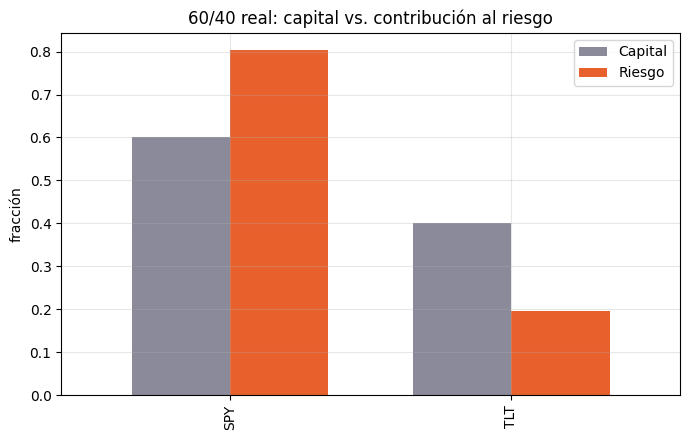


SPY: 60% del capital → 80% del RIESGO de la cartera


In [18]:
# ── La figura que justifica todo: contribuciones al riesgo del 60/40 (datos reales) ──
try:
    px2 = yf.download(['SPY', 'TLT'], period='10y', progress=False)['Close'].dropna()
    fuente2 = 'datos en vivo'
except Exception as e:
    fuente2 = f'⚠ respaldo sintético ({e})'
    rng = np.random.default_rng(15)
    idx = pd.date_range('2016-09-01', periods=2500, freq='B')
    px2 = pd.DataFrame({'SPY': 100*np.exp(np.cumsum(rng.normal(0.0003, 0.011, 2500))),
                        'TLT': 100*np.exp(np.cumsum(rng.normal(0.0001, 0.007, 2500)))}, index=idx)

r2 = np.log(px2/px2.shift(1)).dropna()[['SPY', 'TLT']]
S2 = r2.cov().values * 252
sig_spy, sig_tlt = np.sqrt(np.diag(S2))
rho_spy_tlt = S2[0,1] / (sig_spy*sig_tlt)
print(f'[{fuente2}] σ_SPY={sig_spy:.1%}  σ_TLT={sig_tlt:.1%}  ρ={rho_spy_tlt:+.2f}')

w_6040 = np.array([0.6, 0.4])
def contribuciones(w, S):
    w = np.asarray(w, dtype=float)
    var_p = w @ S @ w
    return w * (S @ w) / var_p

rc = contribuciones(w_6040, S2)
df_rc = pd.DataFrame({'Capital': w_6040, 'Riesgo': rc}, index=['SPY', 'TLT'])
ax = df_rc.plot.bar(figsize=(7, 4.5), color=[MGRAY, ORANGE], width=0.7)
ax.set_ylabel('fracción'); ax.set_title('60/40 real: capital vs. contribución al riesgo')
plt.tight_layout(); plt.show()

print(f'\nSPY: {w_6040[0]:.0%} del capital → {rc[0]:.0%} del RIESGO de la cartera')

[datos en vivo] 4889 días, 2007-04-12 → 2026-09-16
1/N            ret=4.86%  vol=11.26%  Sharpe=0.43  MaxDD=-36.89%
Risk Parity    ret=4.03%  vol=8.21%  Sharpe=0.49  MaxDD=-24.55%


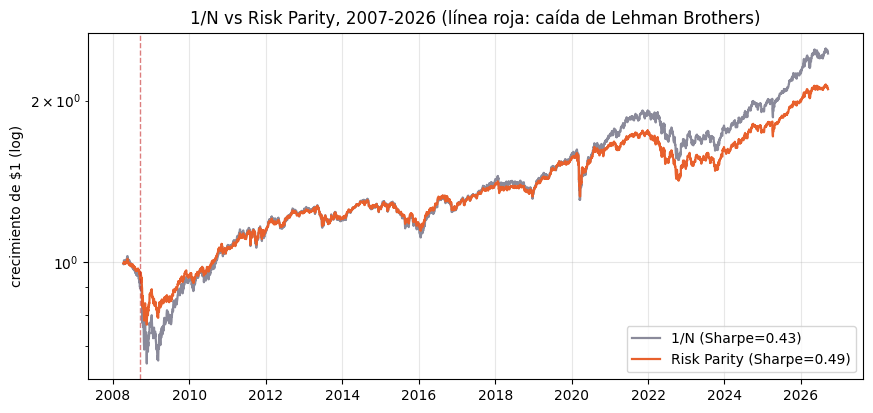

In [19]:
# ── El backtest walk-forward: 8 ETFs, 2007-2026 (con la crisis de 2008 adentro) ──
TICKERS3 = ['SPY', 'EEM', 'VNQ', 'TLT', 'IEF', 'HYG', 'GLD', 'DBC']
n3 = len(TICKERS3)

try:
    px3 = yf.download(TICKERS3, start='2007-04-11', progress=False)['Close'].dropna()[TICKERS3]
    fuente3 = 'datos en vivo'
except Exception as e:
    fuente3 = f'⚠ respaldo sintético ({e})'
    rng = np.random.default_rng(22)
    idx = pd.date_range('2007-04-11', periods=4900, freq='B')
    true_vol = np.array([0.16, 0.22, 0.18, 0.10, 0.05, 0.09, 0.15, 0.20])
    base = rng.normal(0, 1, (4900, n3)) * true_vol / np.sqrt(252)
    px3 = pd.DataFrame(100*np.exp(np.cumsum(base, axis=0)), index=idx, columns=TICKERS3)

r3 = np.log(px3/px3.shift(1)).dropna()[TICKERS3]
print(f'[{fuente3}] {len(r3)} días, {r3.index[0].date()} → {r3.index[-1].date()}')

est_window, rebal_freq = 252, 63   # ventana de 1 año, rebalanceo trimestral
w_ew3, w_rp3 = np.ones(n3)/n3, np.ones(n3)/n3
ret_ew, ret_rp = [], []
for i in range(est_window, len(r3)):
    if (i - est_window) % rebal_freq == 0:
        hist = r3.iloc[i-est_window:i]
        vol_hist = hist.std() * np.sqrt(252)
        iv = 1 / vol_hist
        w_rp3 = (iv / iv.sum()).values
        w_ew3 = np.ones(n3) / n3
    r_t = r3.iloc[i].values
    ret_ew.append(w_ew3 @ r_t); ret_rp.append(w_rp3 @ r_t)

idx_bt = r3.index[est_window:]
ret_ew, ret_rp = pd.Series(ret_ew, index=idx_bt), pd.Series(ret_rp, index=idx_bt)

def stats3(r, start=None, end=None):
    rr = r if start is None else r[start:end]
    wealth = np.exp(rr.cumsum())
    ann_ret, ann_vol = rr.mean()*252, rr.std()*np.sqrt(252)
    sharpe = ann_ret / ann_vol
    maxdd = (wealth / wealth.cummax() - 1).min()
    return wealth, ann_ret, ann_vol, sharpe, maxdd

plt.figure()
for nombre, r, color in [('1/N', ret_ew, MGRAY), ('Risk Parity', ret_rp, ORANGE)]:
    wealth, ar, av, sh, dd = stats3(r)
    plt.plot(wealth.index, wealth.values, color=color, lw=1.6, label=f'{nombre} (Sharpe={sh:.2f})')
    print(f'{nombre:<14} ret={ar:.2%}  vol={av:.2%}  Sharpe={sh:.2f}  MaxDD={dd:.2%}')
plt.axvline(pd.Timestamp('2008-09-15'), color=RED, ls='--', lw=1, alpha=0.6)
plt.legend(); plt.ylabel('crecimiento de $1 (log)'); plt.yscale('log')
plt.title('1/N vs Risk Parity, 2007-2026 (línea roja: caída de Lehman Brothers)')
plt.show()

In [20]:
# ── Bonus: ¿el resultado depende del régimen? Comparar dos ventanas ──────────
print(f'{"":<14}{"2008-2020":>28}{"2016-2026":>28}')
print(f'{"":<14}{"(crisis + recuperación)":>28}{"(bull run reciente)":>28}')
for nombre, r in [('1/N', ret_ew), ('Risk Parity', ret_rp)]:
    _, _, _, sh1, dd1 = stats3(r, '2008-01-01', '2020-12-31')
    _, _, _, sh2, dd2 = stats3(r, '2016-01-01', '2026-12-31')
    print(f'{nombre:<14}   Sharpe={sh1:>6.2f} MaxDD={dd1:>7.1%}      Sharpe={sh2:>6.2f} MaxDD={dd2:>7.1%}')

print()
print('Risk Parity le gana a 1/N en la ventana con la crisis adentro (2008-2020) por más margen')
print('que en la ventana reciente — la crisis es donde el método justifica su existencia.')

                                 2008-2020                   2016-2026
                   (crisis + recuperación)         (bull run reciente)
1/N              Sharpe=  0.36 MaxDD= -36.9%      Sharpe=  0.74 MaxDD= -19.4%
Risk Parity      Sharpe=  0.48 MaxDD= -24.6%      Sharpe=  0.69 MaxDD= -19.4%

Risk Parity le gana a 1/N en la ventana con la crisis adentro (2008-2020) por más margen
que en la ventana reciente — la crisis es donde el método justifica su existencia.
